In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [4]:
from outils import *

In [2]:
CONFIG = {
    
    'classes': ['canette', 'organique', 'plastique', 'textile', 'verre'],
}


In [4]:
initial_learning_rate = 1e-4
epochs = 100
batch_size = 32
num_classes = len(CONFIG['classes'])

In [6]:
df = Load_data.load_object("dataset2.zip", min_images_per_class= 150)

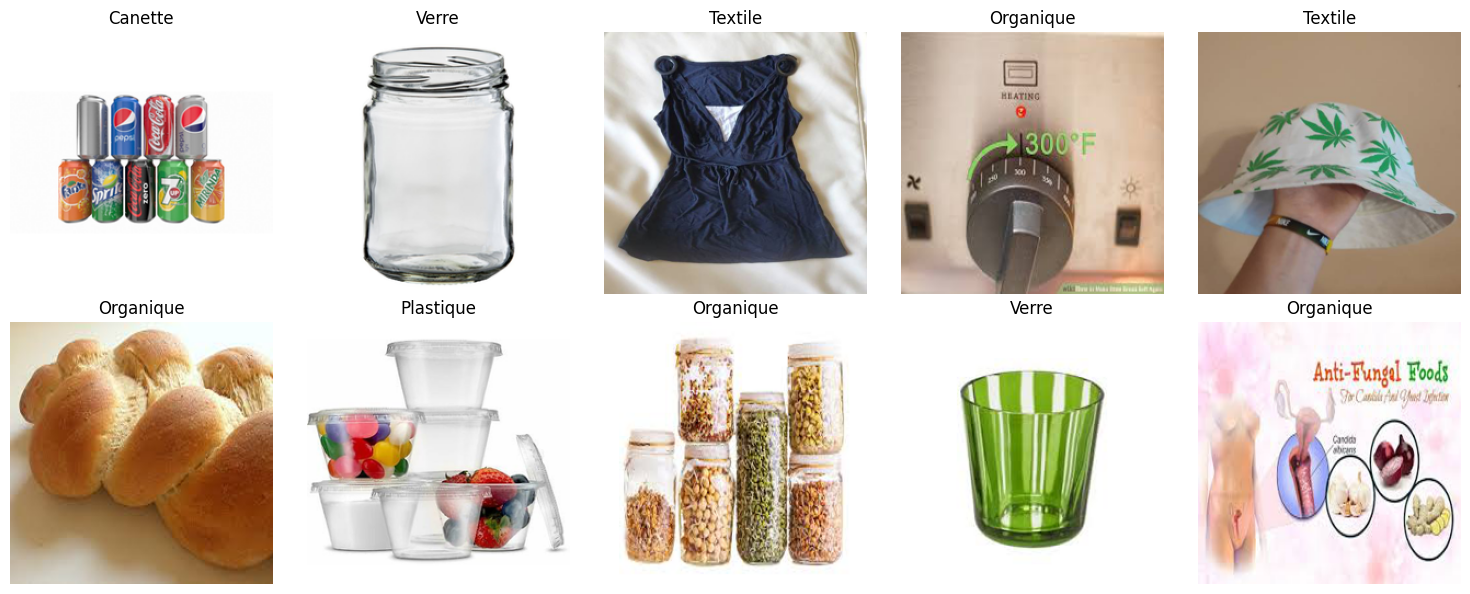

In [7]:
df.plot(n_samples=10)

In [8]:
df.reshape(target_shape=(224, 224, 3))

Reshape en batch:   0%|          | 0/380 [00:00<?, ?it/s]

Reshape en batch: 100%|██████████| 380/380 [00:25<00:00, 14.80it/s]


In [9]:
(X_train, y_train), (X_test, y_test) = df.create_data(test_size=0.2)

Encodage effectué. Mapping: {'Organique': 0, 'Textile': 1, 'Verre': 2, 'Plastique': 3, 'Canette': 4}


In [10]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (9710, 224, 224, 3), Test shape: (2428, 224, 224, 3)


In [11]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,          
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    channel_shift_range=0.2,
    fill_mode='nearest',           
    dtype='float32'                
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)


train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=32,
    shuffle=True,
    seed=42                         
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=32,
    shuffle=False,
    seed=42
)

In [21]:
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

base_model = EfficientNetB0(
    weights='imagenet',        
    include_top=False,         
    input_shape=(224, 224, 3)
)
base_model.trainable = False   

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  
x = GlobalAveragePooling2D()(x)
                      
x = Dense(128, activation='relu')(x)

outputs = Dense(num_classes, activation='softmax')(x)

classifier = Model(inputs, outputs)

In [22]:
classifier.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
from tensorflow.keras.optimizers import RMSprop

In [17]:
from sklearn.utils import class_weight

In [ ]:
weights = class_weight.compute_class_weight(class_weight='balanced',
                                           classes=np.unique(y_train),
                                             y=y_train)
class_weights = dict(enumerate(weights))

In [19]:
class_weights

{0: np.float64(1.0440860215053764),
 1: np.float64(0.9203791469194312),
 2: np.float64(0.8835304822565969),
 3: np.float64(0.9296314025849689),
 4: np.float64(1.3365450791465932)}

In [23]:
import time
initial_learning_rate = 1e-4
param_surv_app1 = ModelCheckpoint("EfficientNetB0_1.keras",monitor="val_accuracy",verbose=1,save_best_only=True,mode="auto")
param_surv_app2 = EarlyStopping(monitor='val_loss',patience=30,verbose=1,mode="auto", restore_best_weights=True)
param_surv_app3 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience= 10, verbose=1)
classifier.compile(optimizer=RMSprop(learning_rate=initial_learning_rate),loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Entrainement du modele
start_time = time.time()
historique=classifier.fit(train_generator,
                     epochs=300,
                     verbose=1,
                     validation_data=test_generator,
                     class_weight=class_weights,
                     callbacks=[param_surv_app1,param_surv_app2,param_surv_app3])
end_time = time.time()
elapsed = end_time - start_time
days, rem = divmod(elapsed, 86400)          
hours, rem = divmod(rem, 3600)
minutes, seconds = divmod(rem, 60)

print(f"Temps d'entraînement : {int(days)}j {int(hours):02d}h {int(minutes):02d}m {int(seconds):02d}s")

Epoch 1/300
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.6625 - loss: 0.9804
Epoch 1: val_accuracy improved from None to 0.89168, saving model to EfficientNetB0_1.keras

Epoch 1: finished saving model to EfficientNetB0_1.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 281s 904ms/step - accuracy: 0.7832 - loss: 0.6680 - val_accuracy: 0.8917 - val_loss: 0.3353 - learning_rate: 1.0000e-04
Epoch 2/300
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.8876 - loss: 0.3320
Epoch 2: val_accuracy improved from 0.89168 to 0.92298, saving model to EfficientNetB0_1.keras

Epoch 2: finished saving model to EfficientNetB0_1.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 286s 941ms/step - accuracy: 0.8851 - loss: 0.3311 - val_accuracy: 0.9230 - val_loss: 0.2467 - learning_rate: 1.0000e-04
Epoch 3/300
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.8975 - loss: 0.2822
Epoch 3: val_accuracy improved from 0.92298 to 0.92916, saving model to EfficientNetB0_1.keras

Epoch 3: finished saving model to Ef

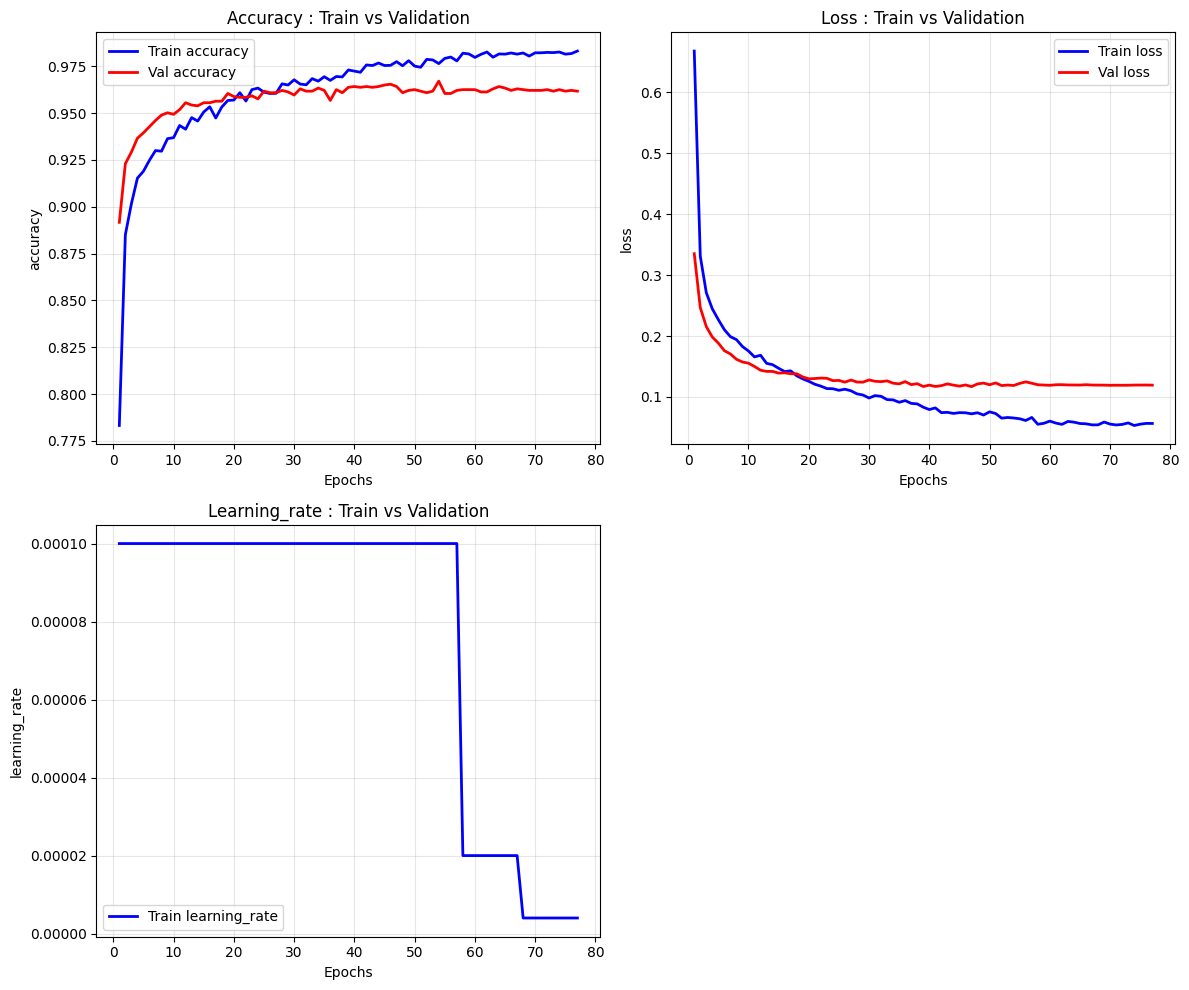

Historique sauvegardé : training_results\plot_EfficientNetB0_history.json
CSV sauvegardé : training_results\plot_EfficientNetB0_history.csv


In [24]:
plot_result(historique,name_fig="plot_EfficientNetB0")

In [ ]:
X_test = X_test.astype('float32') / 255

In [12]:
from tensorflow.keras.models import load_model
model = load_model("EfficientNetB0_1.keras")

In [13]:
X_test = preprocess_input(X_test)

In [15]:
df.name_label_

['Organique', 'Textile', 'Verre', 'Plastique', 'Canette']

76/76 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step 
========================================== Confusion Matrix =====================================================
[[463   1   3  14   1]
 [  0 553   0   1   1]
 [  2   0 541  10   5]
 [  4   2  14 471   3]
 [  2   1   8   8 320]]


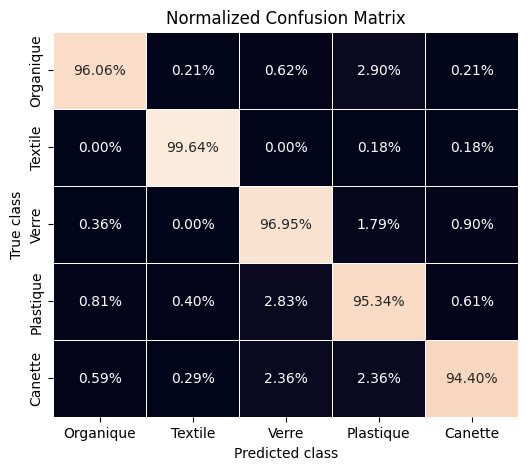

========================================= Detailed Metrics =====================================================
              precision    recall  f1-score   support

   Organique     0.9830    0.9606    0.9717       482
     Textile     0.9928    0.9964    0.9946       555
       Verre     0.9558    0.9695    0.9626       558
   Plastique     0.9345    0.9534    0.9439       494
     Canette     0.9697    0.9440    0.9567       339

    accuracy                         0.9671      2428
   macro avg     0.9672    0.9648    0.9659      2428
weighted avg     0.9673    0.9671    0.9671      2428

Macro F1-score (unweighted): 0.9659
Weighted F1-score: 0.9671


array([4, 2, 3, ..., 2, 1, 2], shape=(2428,))

In [14]:
evaluation(model=model,X_test=X_test,y_test=y_test,labels=df.name_label_)

✅ Modèle YOLO11 créé avec 5 classes + Softmax
